In [1]:
import pandas as pd
import numpy as np 
import json
from data.asset import Asset
from data.processor import calculate_features
from strategy.generator import strategyname, MeanReversionStrategy, TrendFollowingStrategy
from performance.backtest import Backtester
from performance.metrics import max_drawdown, buy_and_hold

In [2]:
with open("config.json") as f:
    config = json.load(f)
config["ticker"]

'INTC'

In [3]:

stock = Asset(ticker=config["ticker"], start=config["start"], end=config["end"])


In [4]:
stock.load_price_data()
stock.data = calculate_features(stock.data)

In [5]:
mean_rev_strat = MeanReversionStrategy(stock.data)
mean_rev_strat.run()

In [6]:
trend_follow_strat = TrendFollowingStrategy(stock.data)
trend_follow_strat.run()

In [7]:
Backtester(stock.data, strategyname.MEAN_REVERSION).test()

{'win_rate': np.float64(0.49920382165605093)}

In [8]:
Backtester(stock.data, strategyname.TREND_FOLLOWING).test()

{'win_rate': np.float64(0.5119426751592356)}

{'max_drawdown': np.float64(-0.5921208402431984),
 'peak_date': Timestamp('2022-06-08 00:00:00-0400', tz='America/New_York'),
 'trough_date': Timestamp('2023-12-15 00:00:00-0500', tz='America/New_York')}

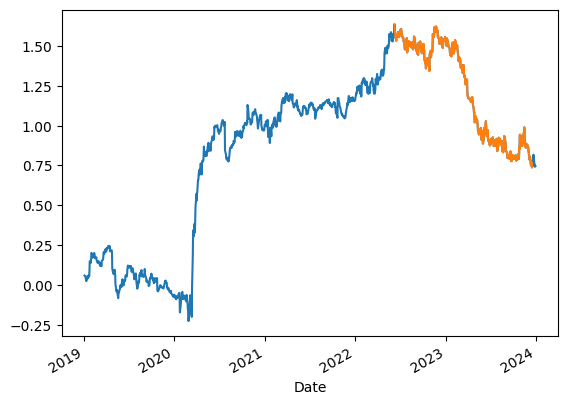

In [9]:
max_drawdown(stock.data, strategyname.MEAN_REVERSION)

{'max_drawdown': np.float64(-0.8446226460888504),
 'peak_date': Timestamp('2020-02-28 00:00:00-0500', tz='America/New_York'),
 'trough_date': Timestamp('2022-06-08 00:00:00-0400', tz='America/New_York')}

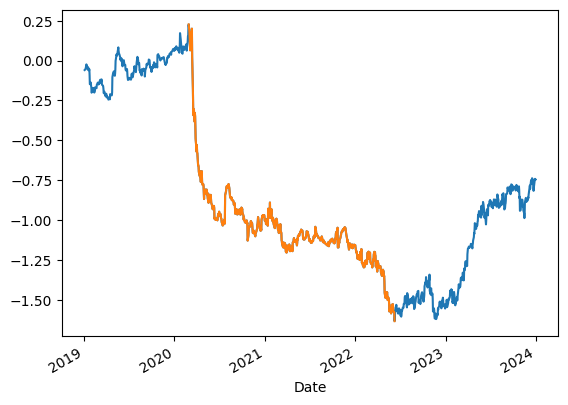

In [10]:
max_drawdown(stock.data, strategyname.TREND_FOLLOWING)

In [11]:
buy_and_hold(stock.data, strategyname.MEAN_REVERSION)

np.float64(0.7467687426091669)

In [12]:
buy_and_hold(stock.data, strategyname.TREND_FOLLOWING)

np.float64(-0.7467687426091669)